In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import pickle
from IPython.display import clear_output
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter1d

In [9]:
file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{2}_attention_test'
data = pickle.load(open(file_path, 'rb'))
def smooth_with_gaussian(data, sigma=2):
    return gaussian_filter1d(data, sigma=sigma, axis=1)  #Gaussian filter along the time axis

def preprocess(data):
    """
    Z-score normalization across trials, for each time and neuron.
    After normalization, subtract the grand mean (across all trials and timepoints) to ensure zero-mean data for spectral analysis.
    """
    data_z = np.zeros_like(data)
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1  # Avoid division by zero by setting std to 1 where it is 0
    data_z = (data - mean) / std
    # Subtract grand mean to ensure zero-mean across all trials and timepoints
    data_z = data_z - np.mean(data_z)
    return data_z

In [4]:
def process_1(data):  #sum, preprocess, smooth
    label_left = data['label_left'][0]
    print(label_left.shape)
    label_right = data['label_right'][0]  #for class of input
    attend_01 = data['attend'][0]
    omitted = data['omit'][0]
    relevant = np.where(omitted == 0)[0]
    print(relevant.shape)
    trial_correct = data['trial_correct'][0]
    relevant = np.where((omitted == 0) & (trial_correct == 1))[0]   
    print(relevant.shape)

    

    

    left = data['SP'][0][0][relevant, 100:350, :]
    right = data['SP'][0][1][relevant, 100:350, :]
    att = data['SP'][0][2][relevant, 100:350, :]

    num_trials, num_samples, num_neurons = left.shape
    num_neurons_attention = 80

    for j in range(0, num_trials):
        for i in range(0, num_neurons):
            count_left = np.count_nonzero(left[j, :, i] == 1)
            if count_left > 0:
                left[j, :, i] /= count_left
            count_right = np.count_nonzero(right[j, :, i] == 1)
            if count_right > 0:
                right[j, :, i] /= count_right


        for i in range(0, num_neurons_attention):
            count_attention = np.count_nonzero(att[j, :, i] == 1)
            if count_attention > 0:
                att[j, :, i] /= count_attention

    left = np.sum(left, axis=2) / 160
    right = np.sum(right, axis=2) / 160
    att = np.sum(att, axis=2) / 80 

    left = preprocess(left)
    right = preprocess(right)
    att = preprocess(att)

    #can now split into left and right attentional modality
    left_indices_agg = np.where((omitted ==0) & (attend_01 == 0) & (label_left != label_right))[0]  #indices of agg where left
    _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   #indices for relevant processed data where attention left
    right_indices_agg = np.where((omitted ==0) & (attend_01 == 1) & (label_left != label_right))[0]
    _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

    #splitting left and right
    left_attleft = smooth_with_gaussian(left[left_indices], sigma = 2)  #axis 1 will smooth all of these across time
    right_attleft = smooth_with_gaussian(right[left_indices], sigma = 2)
    att_attleft = smooth_with_gaussian(att[left_indices], sigma = 2)

    left_attright = smooth_with_gaussian(left[right_indices], sigma = 2)
    print(left_attright.shape)
    right_attright = smooth_with_gaussian(right[right_indices], sigma = 2)
    att_attright =  smooth_with_gaussian(att[right_indices], sigma = 2)

 

    return left_attleft, right_attleft, att_attleft, left_attright, right_attright, att_attright


(2032,)
(990,)
(735,)


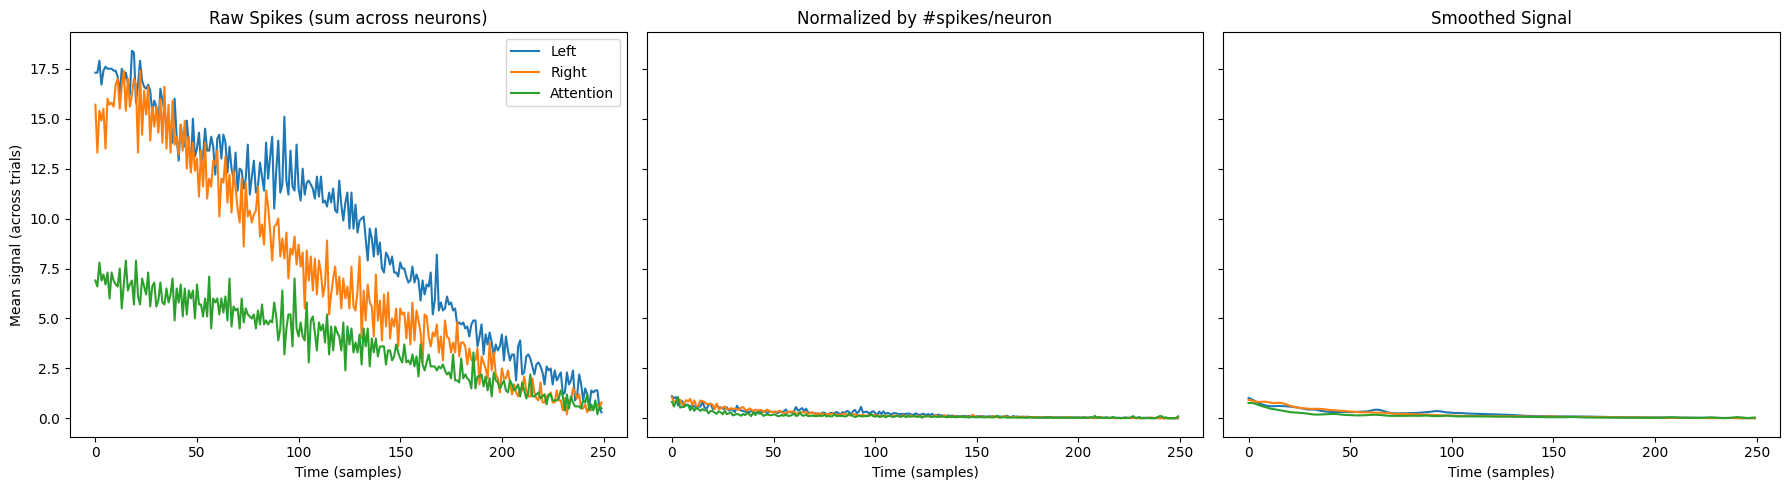

NameError: name 'preprocess' is not defined

In [5]:
l_al1, r_al1, att_al1, l_ar1, r_ar1, att_ar1 = process_1(data)


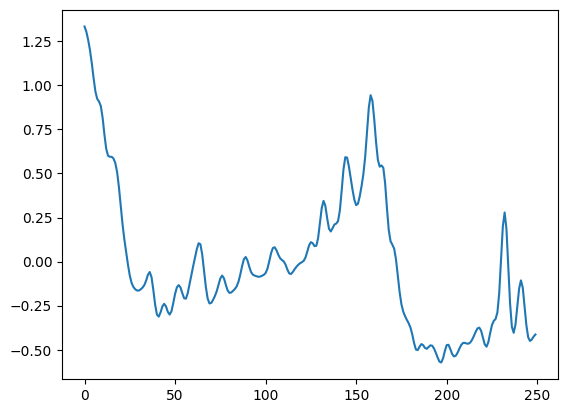

In [55]:
plt.plot(l_al1[3, :])
plt.show()

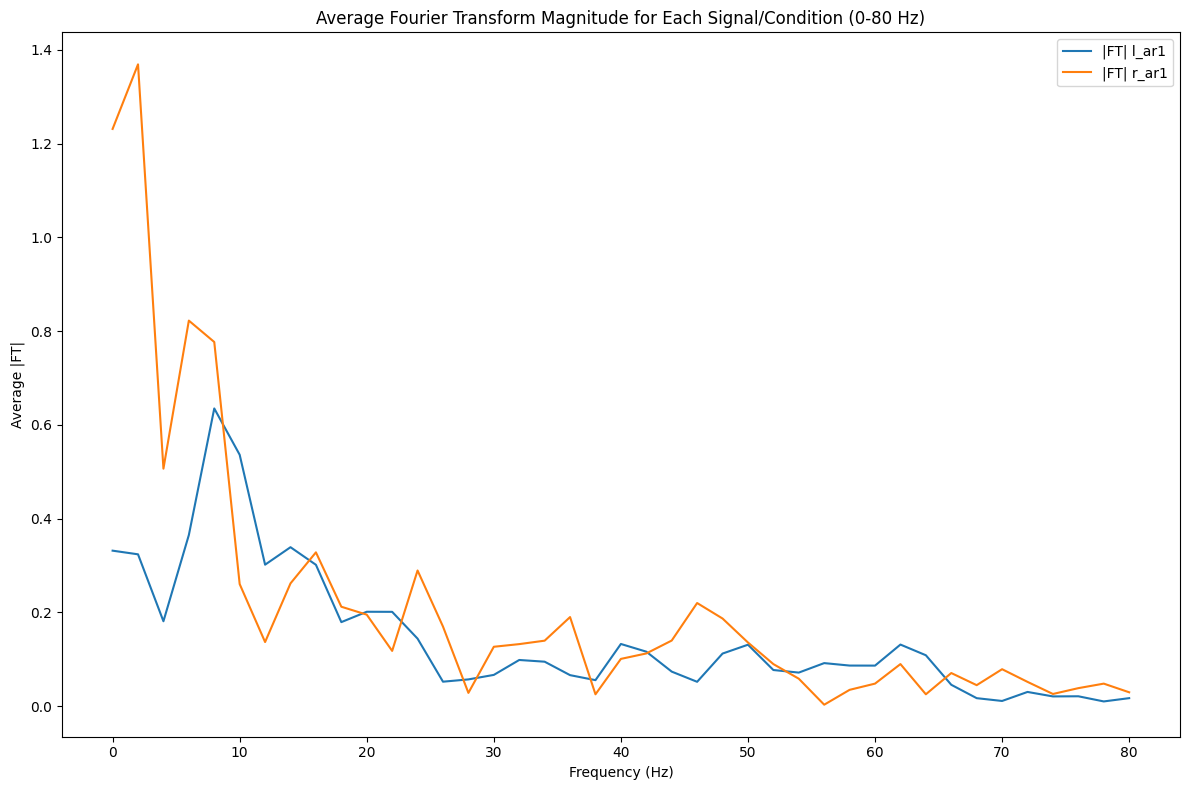

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_average_fourier_transform(trials, dt):
    """
    Compute the average (complex) Fourier transform across trials.
    Args:
        trials: np.ndarray, shape (n_trials, n_timepoints)
        dt: float, time step (inverse of sampling frequency)
    Returns:
        freqs: frequency bins
        avg_ft: average complex FT across trials (can be used for phase analysis)
    """
    n_trials, n_timepoints = trials.shape
    fts = []
    for trial in trials:
        trial = trial - np.mean(trial)  # Detrend the signal
        ft = np.fft.rfft(trial * np.hanning(n_timepoints))
        fts.append(ft)
    fts = np.array(fts)
    avg_ft = np.mean(fts, axis=0)
    freqs = np.fft.rfftfreq(n_timepoints, d=dt)
    return freqs, avg_ft


dt = 0.002  # Set to your actual time step (seconds per sample)

signals = {
    # "l_al1": l_al1,
    # "r_al1": r_ar1,
    # "att_al1": att_al1,
   "l_ar1": l_ar1,
    "r_ar1": r_ar1,
    # "att_ar1": att_ar1,
}

plt.figure(figsize=(12, 8))
for name, data in signals.items():
    freqs, avg_ft = compute_average_fourier_transform(data, dt=dt)
    mask = (freqs >= 0) & (freqs <= 80)
    plt.plot(freqs[mask], np.abs(avg_ft)[mask], label=f"|FT| {name}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Average |FT|")
plt.title("Average Fourier Transform Magnitude for Each Signal/Condition (0-80 Hz)")
plt.legend()
plt.tight_layout()
plt.show()

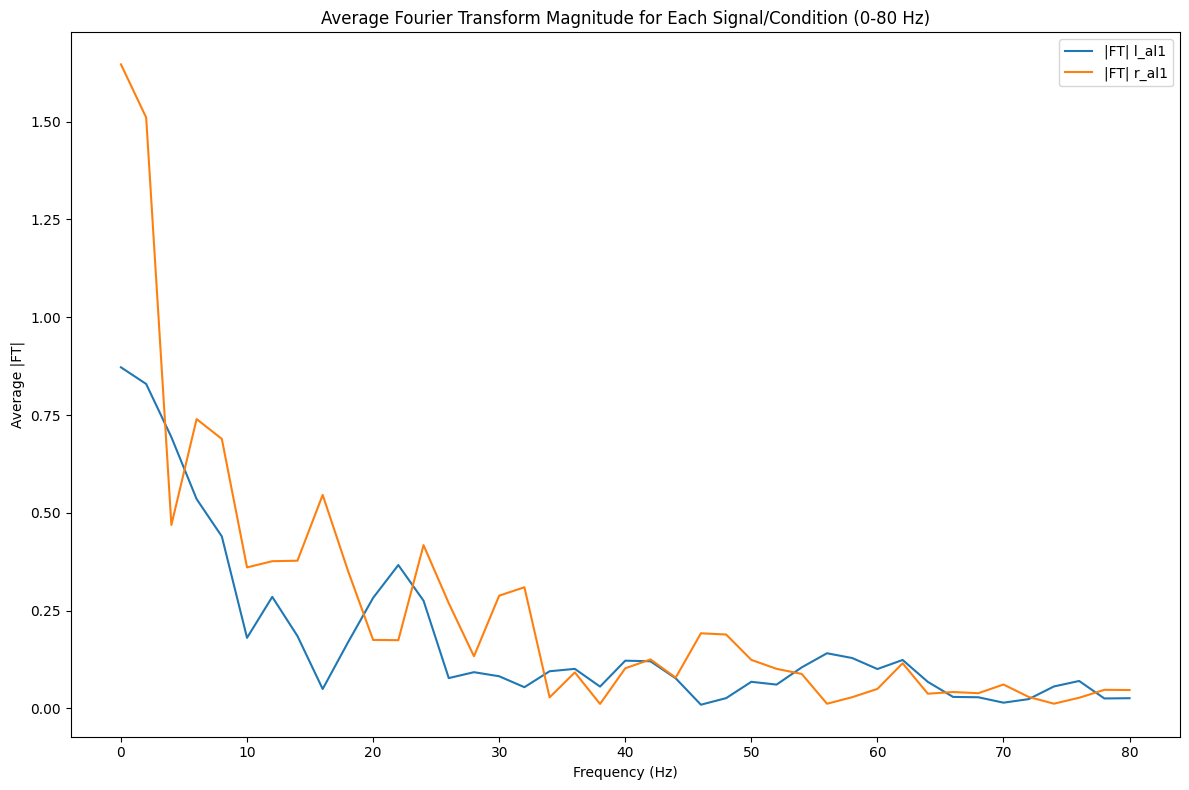

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_average_fourier_transform(trials, dt):
    """
    Compute the average (complex) Fourier transform across trials.
    Args:
        trials: np.ndarray, shape (n_trials, n_timepoints)
        dt: float, time step (inverse of sampling frequency)
    Returns:
        freqs: frequency bins
        avg_ft: average complex FT across trials (can be used for phase analysis)
    """
    n_trials, n_timepoints = trials.shape
    fts = []
    for trial in trials:
        trial = trial - np.mean(trial)  # Detrend the signal
        ft = np.fft.rfft(trial * np.hanning(n_timepoints))
        fts.append(ft)
    fts = np.array(fts)
    avg_ft = np.mean(fts, axis=0)
    freqs = np.fft.rfftfreq(n_timepoints, d=dt)
    return freqs, avg_ft


dt = 0.002  # Set to your actual time step (seconds per sample)

signals = {
    "l_al1": l_al1,
    "r_ar1": r_ar1,
    # "att_al1": att_al1,
#    "l_ar1": l_ar1,
#     "r_ar1": r_ar1,
    # "att_ar1": att_al1,
}

plt.figure(figsize=(12, 8))
for name, data in signals.items():
    freqs, avg_ft = compute_average_fourier_transform(data, dt=dt)
    mask = (freqs >= 0) & (freqs <= 80)
    plt.plot(freqs[mask], np.abs(avg_ft)[mask], label=f"|FT| {name}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Average |FT|")
plt.title("Average Fourier Transform Magnitude for Each Signal/Condition (0-80 Hz)")
plt.legend()
plt.tight_layout()
plt.show()

Average FT at 0 Hz (real): -0.8719185358070816
Average FT at 0 Hz (imag): 0.0
Average FT at 0 Hz (real): 1.6463115235955594
Average FT at 0 Hz (imag): 0.0


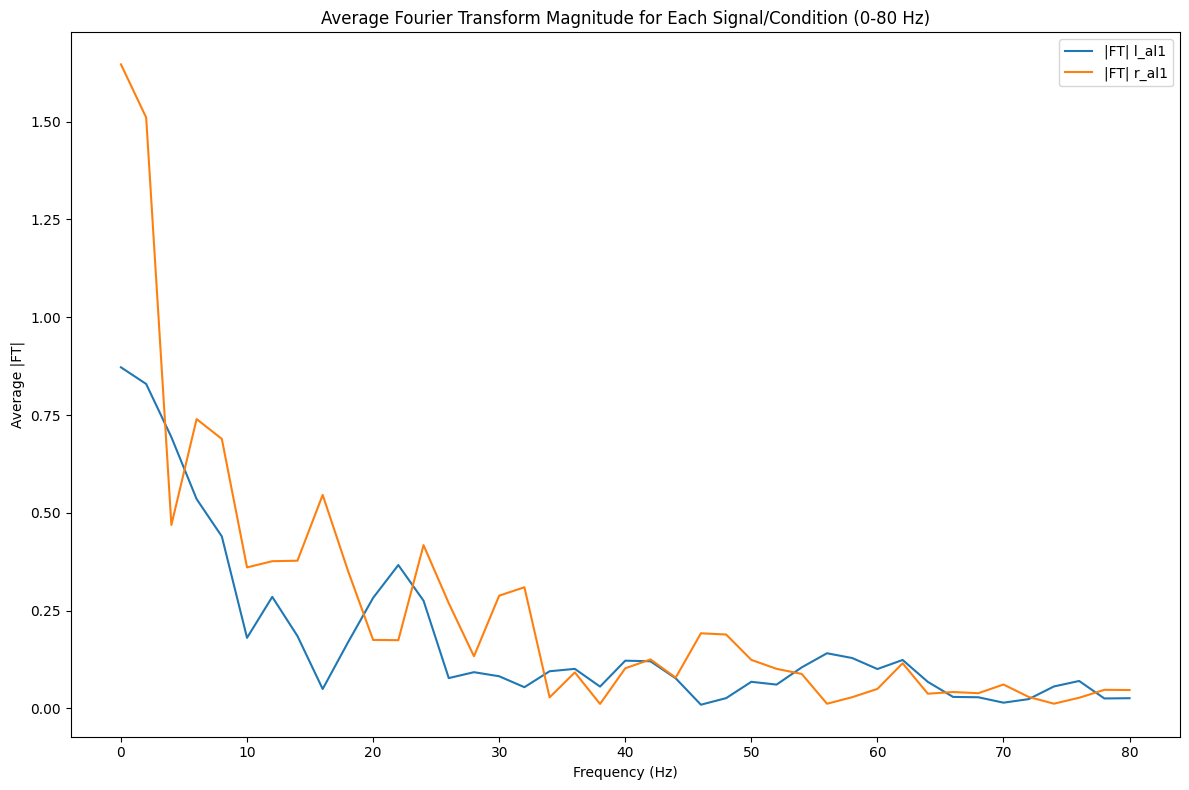

In [ ]:

def compute_average_fourier_transform(trials, dt):
    """
    Compute the average (complex) Fourier transform across trials, with robust mean subtraction.
    Args:
        trials: np.ndarray, shape (n_trials, n_timepoints)
        dt: float, time step (inverse of sampling frequency)
    Returns:
        freqs: frequency bins
        avg_ft: average complex FT across trials (can be used for phase analysis)
    """
    n_trials, n_timepoints = trials.shape
    fts = []
    for trial in trials:
        # Subtract mean after all processing
        trial = trial - np.mean(trial)
        ft = np.fft.rfft(trial * np.hanning(n_timepoints))
        fts.append(ft)
    fts = np.array(fts)
    avg_ft = np.mean(fts, axis=0)
    freqs = np.fft.rfftfreq(n_timepoints, d=dt)
    # Print DC component for inspection
    print("Average FT at 0 Hz (real):", np.real(avg_ft[0]))
    print("Average FT at 0 Hz (imag):", np.imag(avg_ft[0]))
    return freqs, avg_ft

dt = 0.002  # Set to your actual time step (seconds per sample)

signals = {
    "l_al1": l_al1,
    "r_al1": r_ar1,
}

plt.figure(figsize=(12, 8))
for name, data in signals.items():
    freqs, avg_ft = compute_average_fourier_transform(data, dt=dt)
    mask = (freqs >= 0) & (freqs <= 80)
    plt.plot(freqs[mask], np.abs(avg_ft)[mask], label=f"|FT| {name}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Average |FT|")
plt.title("Average Fourier Transform Magnitude for Each Signal/Condition (0-80 Hz)")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{2}_attention_test'
data = pickle.load(open(file_path, 'rb'))
def smooth_with_gaussian(data, sigma=2):
    return gaussian_filter1d(data, sigma=sigma, axis=1)  #Gaussian filter along the time axis

def preprocess(data):
    """
    Z-score normalization across trials, for each time and neuron.
    After normalization, subtract the grand mean (across all trials and timepoints) to ensure zero-mean data for spectral analysis.
    """
    data_z = np.zeros_like(data)
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1  # Avoid division by zero by setting std to 1 where it is 0
    data_z = (data - mean) / std
    # Subtract grand mean to ensure zero-mean across all trials and timepoints
    data_z = data_z - np.mean(data_z)
    return data_z

In [ ]:
label_left = data['label_left'][0]
print(label_left.shape)
label_right = data['label_right'][0]  #for class of input
attend_01 = data['attend'][0]
omitted = data['omit'][0]
relevant = np.where(omitted == 0)[0]
print(relevant.shape)
trial_correct = data['trial_correct'][0]
relevant = np.where((omitted == 0) & (trial_correct == 1))[0]   
print(relevant.shape)

left_indices_agg = np.where((omitted ==0) & (attend_01 == 0) & (label_left != label_right))[0]  #indices of agg where left
_, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   #indices for relevant processed data where attention left
right_indices_agg = np.where((omitted ==0) & (attend_01 == 1) & (label_left != label_right))[0]
_, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

print(left_indices.shape)

num_trials, num_samples, num_neurons = left.shape
num_neurons_attention = 80



(2032,)
(1057,)
(723,)
(328,)


[[[0. 1. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 1. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 1. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 1. 0. 1.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 1. 0. 1.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 1. 0. ... 1. 0. 1.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 1. 0. ... 1. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 1. 0. 1.]
  [0. 1. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 1. 0. 1.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 1. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 1. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


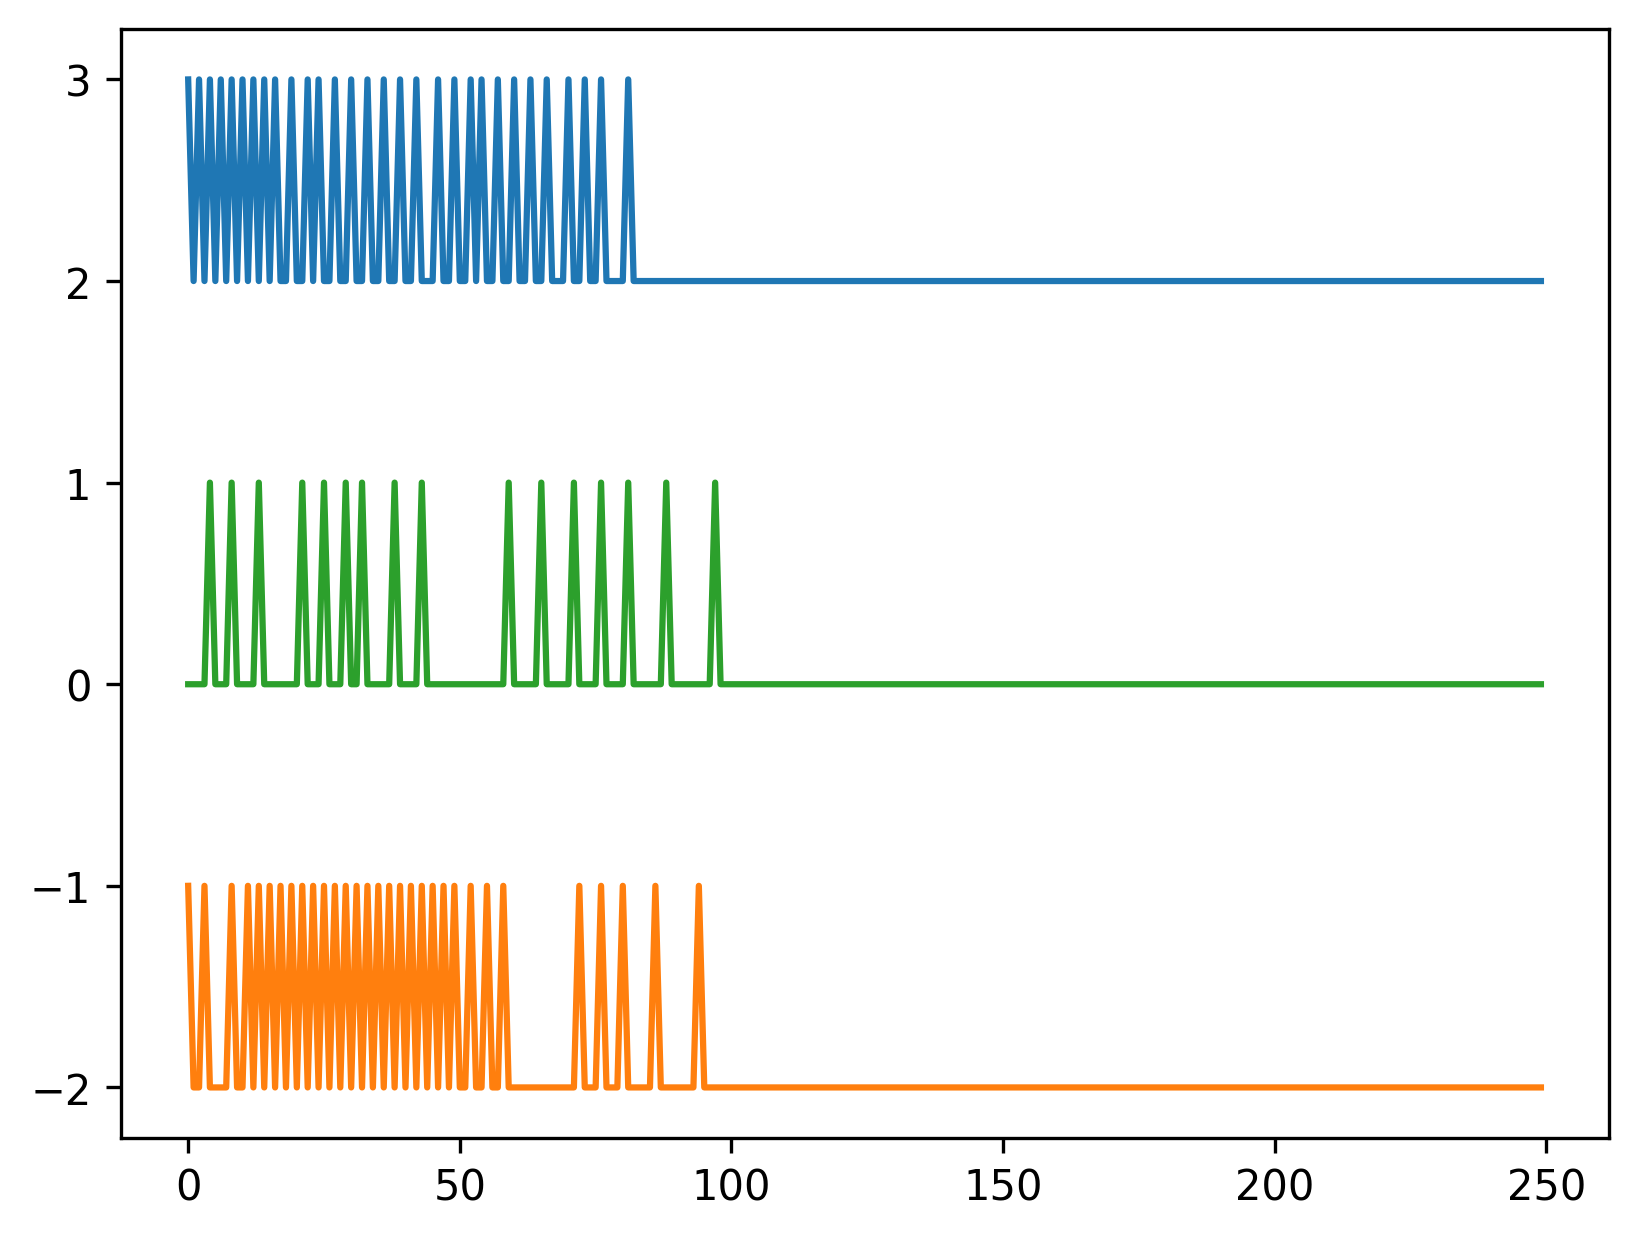

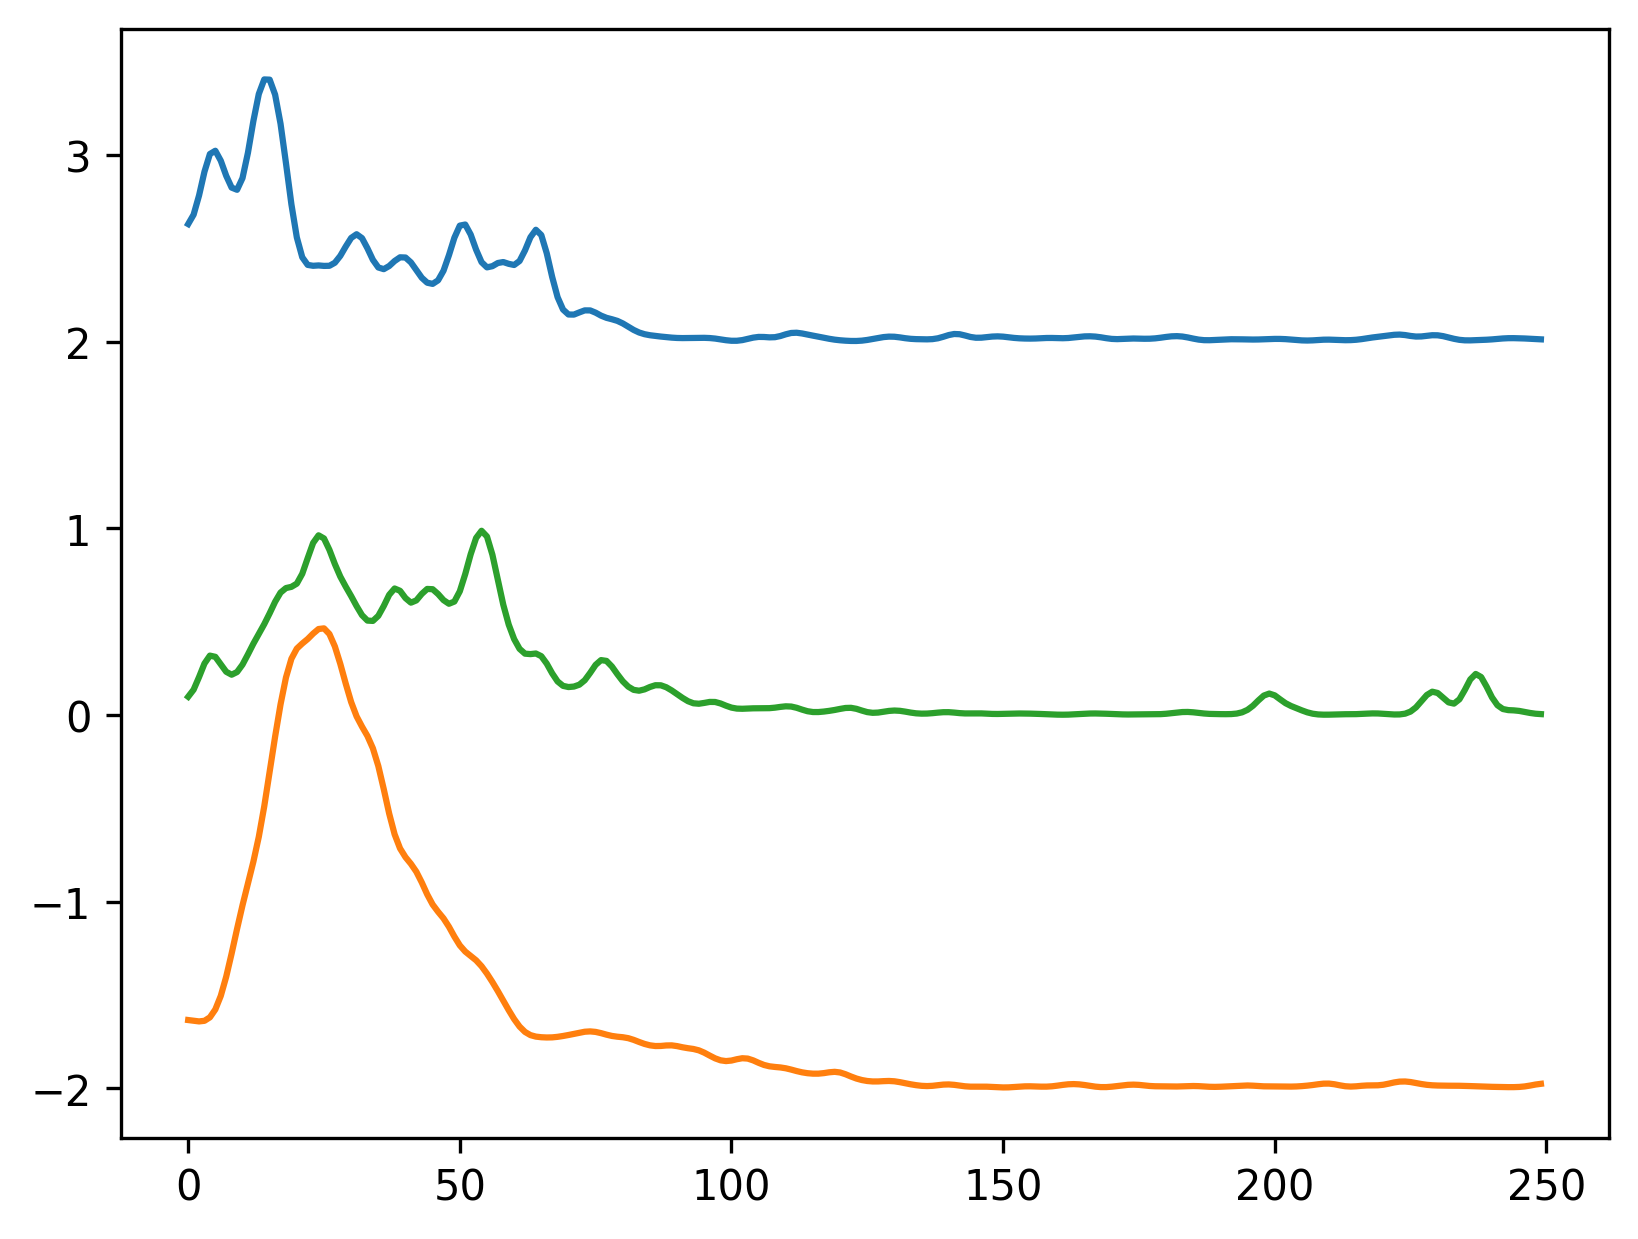

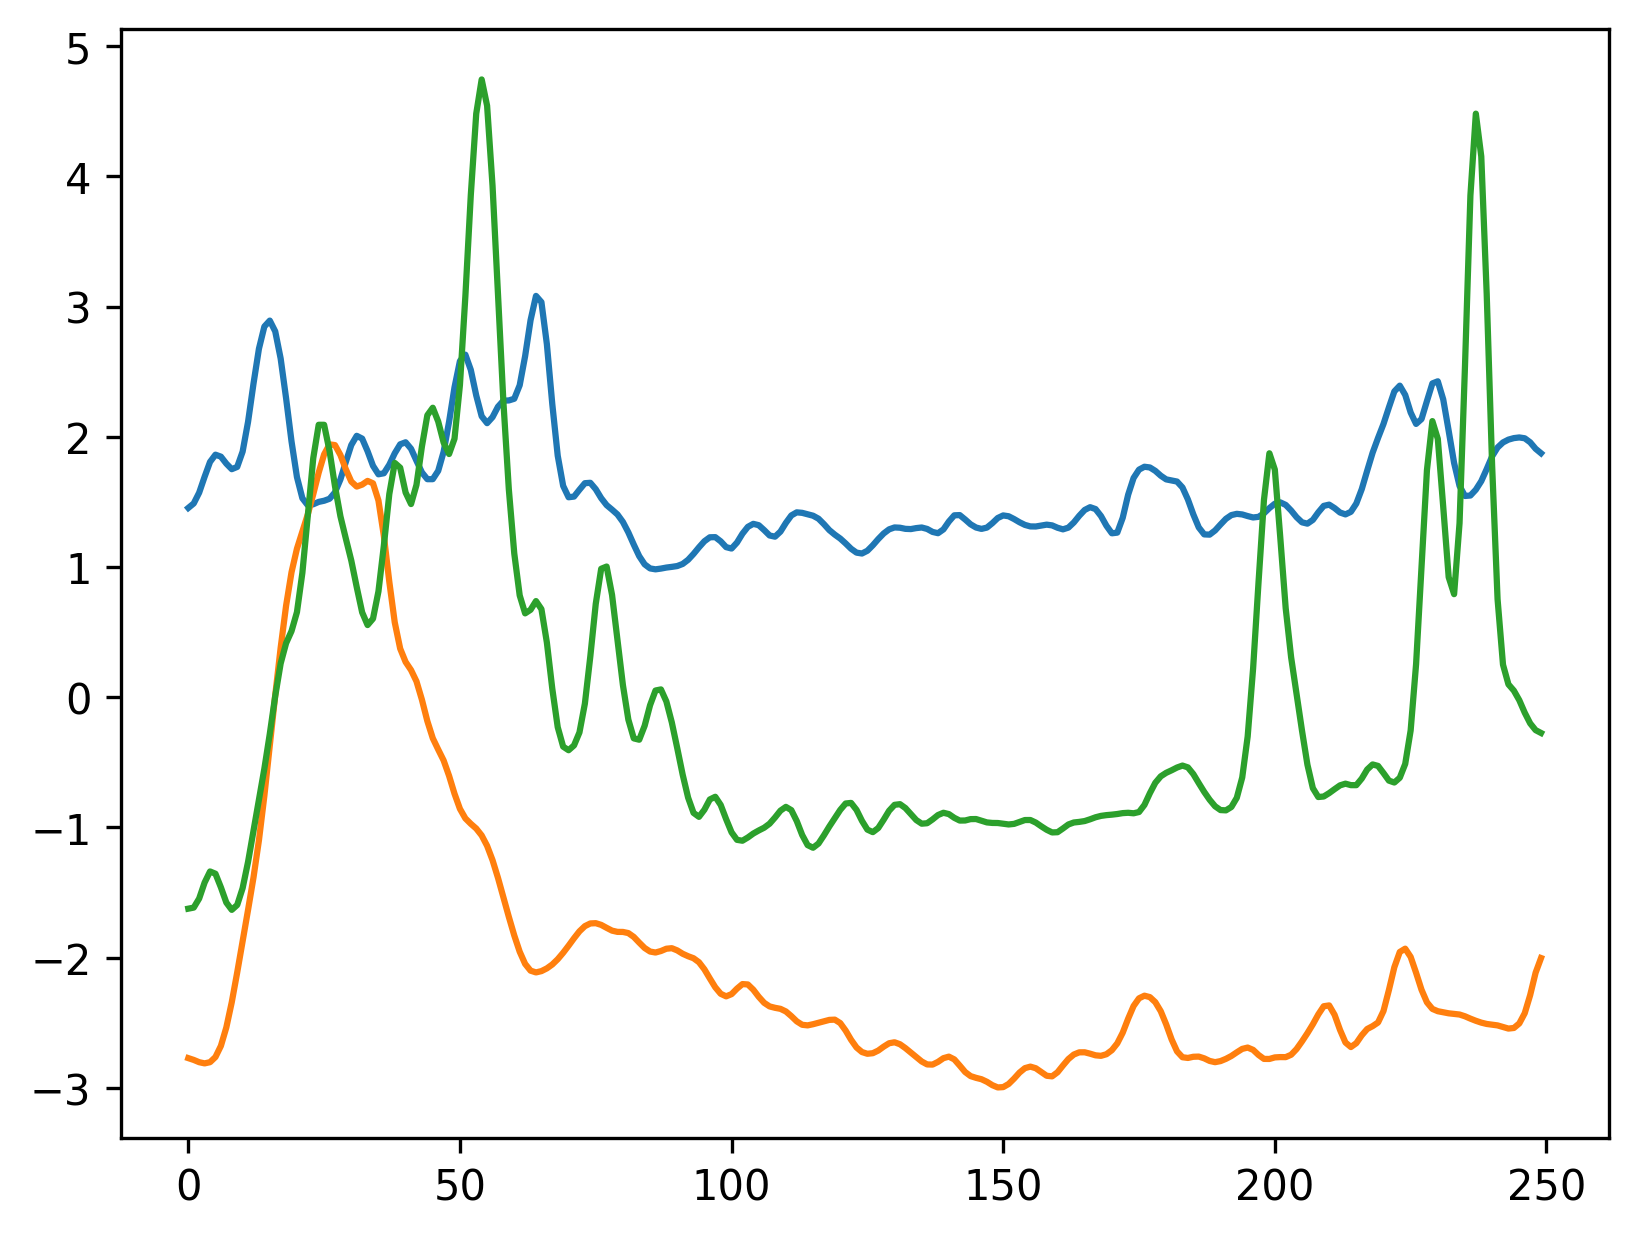

(328, 250)
(350, 250)


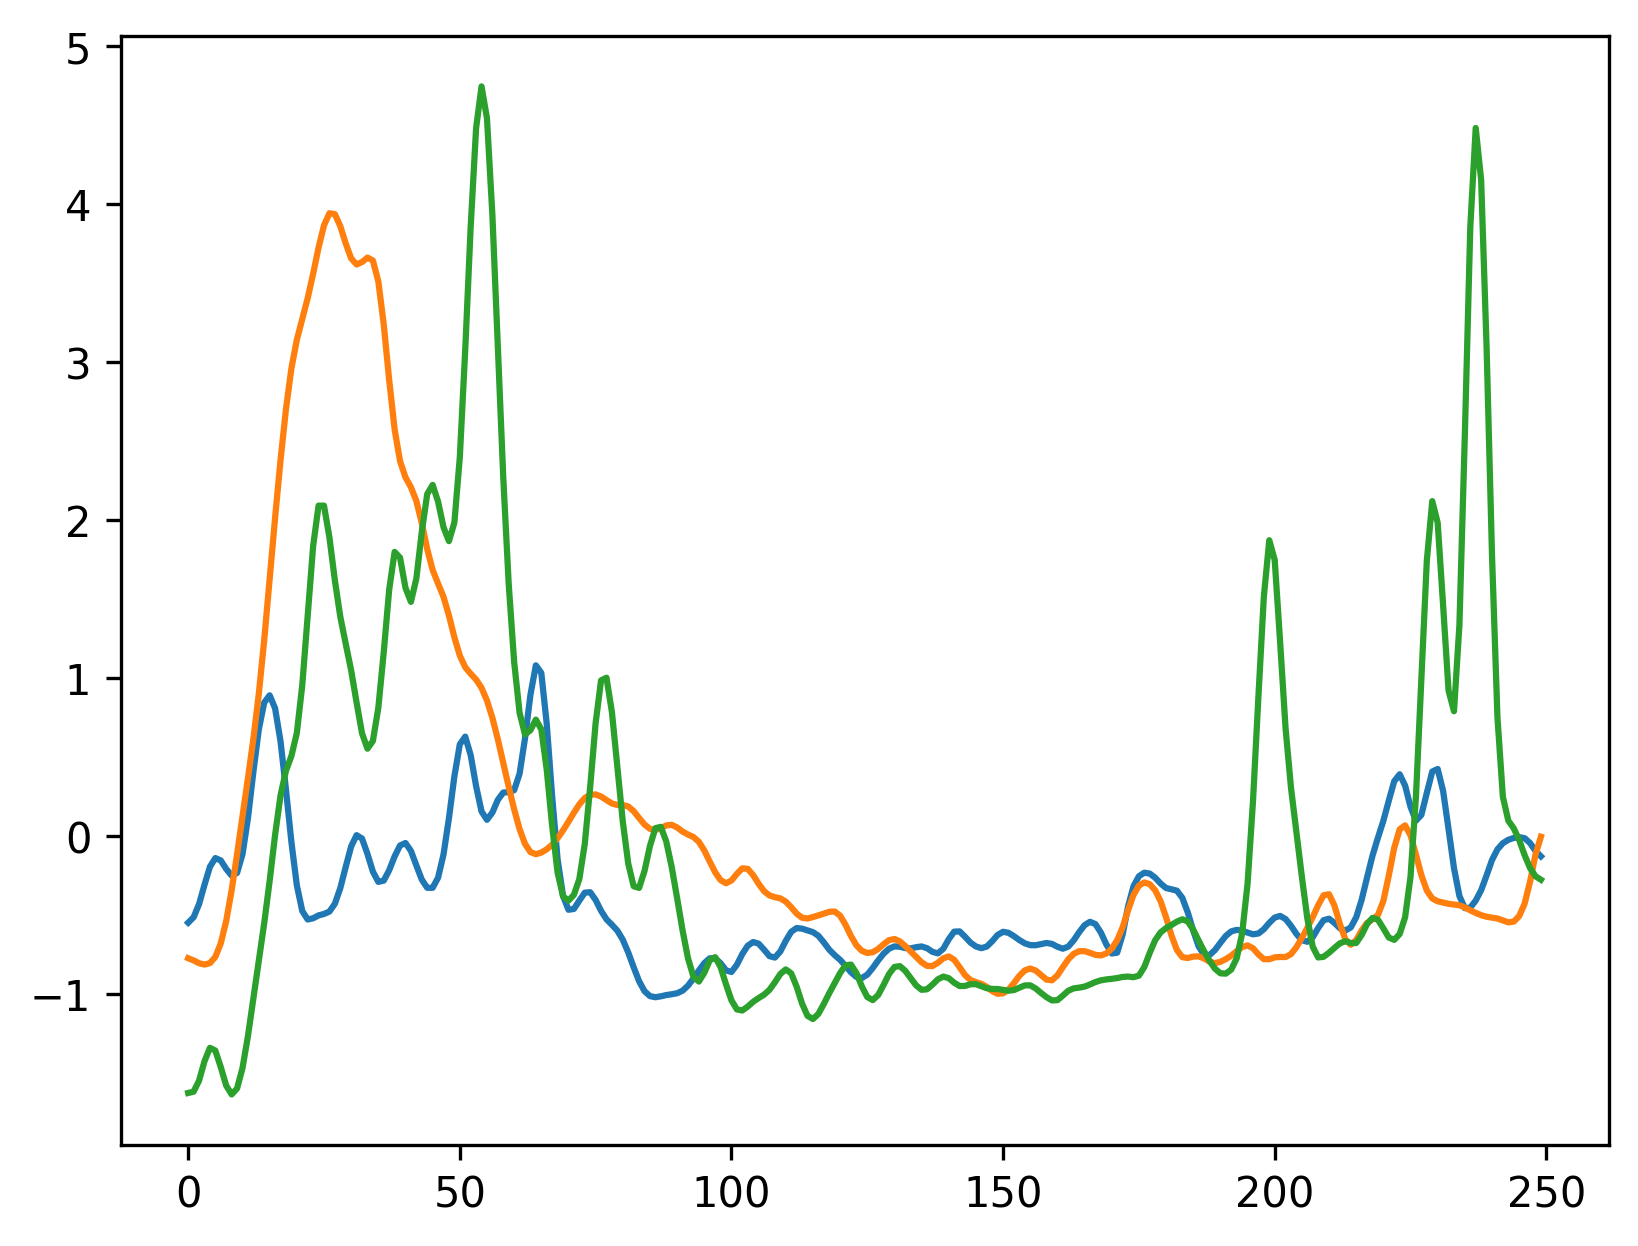

In [114]:
left = data['SP'][0][0][relevant, 100:350, :]
right = data['SP'][0][1][relevant, 100:350, :]
att = data['SP'][0][2][relevant, 100:350, :]

print(right)

# High-res plot for single neuron traces
plt.figure(dpi=300)
plt.plot(left[0, :, 0] + 2)
plt.plot(right[0, :, 1] - 2)
plt.plot(att[0, :, 2])
plt.show()

for j in range(0, num_trials):
    for i in range(0, num_neurons):
        count_left = np.count_nonzero(left[j, :, i] == 1)
        if count_left > 0:
            left[j, :, i] /= count_left
        count_right = np.count_nonzero(right[j, :, i] == 1)
        if count_right > 0:
            right[j, :, i] /= count_right

    for i in range(0, num_neurons_attention):
        count_attention = np.count_nonzero(att[j, :, i] == 1)
        if count_attention > 0:
            att[j, :, i] /= count_attention

left = np.sum(left, axis=2)  # Return a single time series for the output
right = np.sum(right, axis=2)
att = np.sum(att, axis=2)

left = smooth_with_gaussian(left, sigma=2)  # Axis 1 will smooth all of these across time
right = smooth_with_gaussian(right, sigma=2)    
att = smooth_with_gaussian(att, sigma=2)

# High-res plot for summed, smoothed traces
plt.figure(dpi=300)
plt.plot(left[0, :] + 2)
plt.plot(right[0, :] - 2)
plt.plot(att[0, :])
plt.show()

left = preprocess(left)
right = preprocess(right)
att = preprocess(att)

# High-res plot for preprocessed traces
plt.figure(dpi=300)
plt.plot(left[0, :] + 2)
plt.plot(right[0, :] - 2)
plt.plot(att[0, :])
plt.show()


# Can now split into left and right attentional modality
left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
_, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
_, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

l_al = left[left_indices]
print(l_al.shape)
r_al = right[left_indices]
a_al = att[left_indices]

l_ar = left[right_indices]
print(l_ar.shape)
r_ar = right[right_indices]
a_ar = att[right_indices]

# High-res plot for split attention conditions
plt.figure(dpi=300)
plt.plot(l_al[0, :])
plt.plot(r_al[0, :])
plt.plot(a_al[0, :])
plt.show()

